In [1]:
# ─── COLUMNAS ────────────────────────────────────────────────────────────────
REVIEW_COL      = 'review'
SENTIMIENTO_COL = 'sentimiento'

# ─── MODO ────────────────────────────────────────────────────────────────────
# 'train'      → entrenar desde cero
# 'load_hf'    → cargar modelo de HuggingFace Hub
MODE = 'train'

LOCAL_MODEL_PATH = '../results/bertopic_model'
HF_MODEL_ID      = 'MaartenGr/BERTopic_ArXiv' 

# ─── DATOS ───────────────────────────────────────────────────────────────────
# True  → BERTopic sobre oraciones individuales (detecta múltiples aspectos por review)
# False → BERTopic sobre reviews completas (más rápido, pero 1 tópico por review)
USE_SENTENCES = True

# ─── ENTRENAMIENTO ───────────────────────────────────────────────────────────
# True  → semi-supervisado con seed topics (guía el modelo hacia los 7 temas)
USE_SEED_TOPICS = True

MIN_TOPIC_SIZE  = 20   # mínimo de documentos para formar un tópico
REDUCE_OUTLIERS = True
OUTLIER_THRESHOLD = 0.1

RANDOM_STATE = 42

In [2]:
import sys, re
sys.path.append('..')

import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import spacy
matplotlib.rcParams['figure.dpi'] = 120
from tqdm.auto import tqdm
from collections import defaultdict, Counter

from bertopic import BERTopic
from bertopic.representation import (
    KeyBERTInspired,
    MaximalMarginalRelevance,
    PartOfSpeech,
    ZeroShotClassification,
)
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from pysentimiento import create_analyzer

c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\.venv-2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#!pip install torch==2.11.0+cu126 --index-url https://download.pytorch.org/whl/cu126
!pip install -r requirements.txt

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
      --------------------------------------- 0.3/12.9 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.9 MB 1.2 MB/s eta 0:00:11
     -- ------------------------------------- 0.8/12.9 MB 1.2 MB/s eta 0:00:11
     --- ------------------------------------ 1.0/12.9 MB 1.2 MB/s eta 0:00:10
     ---- ----------------------------------- 1.3/12.9 MB 1.2 MB/s eta 0:00:10
     ---- ----------------------------------- 1.6/12.9 MB 1.2 MB/s eta 0:00:10
     ----- ---------------------------------- 1.8/12.9 MB 1.2 MB/s eta 0:00:10
     ------ --------------------------------- 2.1/12.9 MB 1.2 MB/s eta 0:00:10
     ------- -------------------------------- 2.4/12.9 MB 1.1 MB/s eta 0:00:10
     -------- ------------------------------- 2.6/12.9 MB 1.2 MB/s eta 0:00:09
     -------- ------------------------------- 2.9/12.9 MB 1.2 MB/s eta 0:

In [4]:
!pip uninstall -y transformers accelerate tokenizers
!pip install transformers accelerate tokenizers sentence-transformers

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2


You can safely remove it manually.


  Using cached transformers-5.5.3-py3-none-any.whl.metadata (32 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached huggingface_hub-1.10.1-py3-none-any.whl.metadata (14 kB)
Using cached transformers-5.5.3-py3-none-any.whl (10.2 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached huggingface_hub-1.10.1-py3-none-any.whl (642 kB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 0.36.2

    Uninstalling huggingface_hub-0.36.2:

      Successfully uninstalled huggingface_hub-0.36.2

   ---------------------------------------- 0/4 [huggingface-hub]
   ---------------------------------------- 0/4 [huggingface-hub]
   ---------------------------------------- 0/4 [huggingface-hub]
   ---------------------------------------- 0/4 [huggingface-hub]
   -------------

In [5]:
df = pd.read_csv('../data/reviews_clean.csv')
print(f'{len(df)} reviews — columnas: {list(df.columns)}')

8076 reviews — columnas: ['review', 'sentimiento']


In [6]:
df = df[:1000]  # para pruebas rápidas

In [7]:
nlp = spacy.load('es_core_news_sm', disable=['ner', 'parser'])
nlp.add_pipe('sentencizer')

STOPWORDS_HOTEL = {
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las',
    'un', 'por', 'con', 'una', 'su', 'para', 'es', 'al', 'lo', 'como',
    'mas', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'si', 'porque', 'esta',
    'entre', 'cuando', 'muy', 'sin', 'sobre', 'ser', 'tiene', 'le', 'desde',
    'nos', 'todo', 'uno', 'donde', 'bien', 'fue', 'era', 'hay', 'muy',
    'me', 'ni', 'mi', 'te', 'han', 'esta', 'he', 'no', 'son', 'tan',
    'tambien', 'si', 'queda', 'solo', 'aunque', 'eso', 'todo', 'nada',
    'hotel'
}

def limpiar_texto(texto: str) -> str:
    texto = texto.lower().strip()
    texto = re.sub(r'http\S+', '', texto)
    texto = re.sub(r'[^a-záéíóúüñ\s.,!?]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

def segmentar_oraciones(texto: str, min_palabras: int = 4) -> list:
    """Divide una review en oraciones de al menos min_palabras palabras."""
    doc = nlp(texto[:1000000])  # límite por seguridad
    oraciones = []
    for sent in doc.sents:
        sent_text = sent.text.strip()
        if len(sent_text.split()) >= min_palabras:
            oraciones.append(sent_text)
    return oraciones if oraciones else [texto]

In [8]:
df['review_limpia'] = df[REVIEW_COL].fillna('').apply(limpiar_texto)

print('Segmentando reviews en oraciones...')
filas = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    oraciones = segmentar_oraciones(row['review_limpia'])
    for oracion in oraciones:
        fila = {'review_idx': idx, 'oracion': oracion}
        if SENTIMIENTO_COL in df.columns:
            fila['sentimiento_global'] = row[SENTIMIENTO_COL]
        filas.append(fila)

df_oraciones = pd.DataFrame(filas)
df_oraciones = df_oraciones.drop_duplicates(subset='oracion').reset_index(drop=True)

print(f'Reviews originales:        {len(df):,}')
print(f'Oraciones generadas:       {len(df_oraciones):,}')
print(f'Promedio oraciones/review: {len(df_oraciones)/len(df):.1f}')
df_oraciones.head(5)

Segmentando reviews en oraciones...


100%|██████████| 1000/1000 [00:08<00:00, 122.22it/s]

Reviews originales:        1,000
Oraciones generadas:       4,494
Promedio oraciones/review: 4.5


,review_idx,oracion,sentimiento_global
0,0,el fin de semana mi pareja y yo hicimos una re...,negativo
1,0,persona llevaron a un ala bastante apartada de...,negativo
2,0,nos pareció bien porque era justo lo que buscá...,negativo
3,0,"desde las de la mañana con ruidos, primero lo ...",negativo
4,0,habíamos cogido sólo alojamiento para descansa...,negativo


In [9]:
# Seleccionar unidad de análisis según configuración
if USE_SENTENCES:
    docs = df_oraciones['oracion'].tolist()
    print(f'Unidad de análisis: oraciones ({len(docs):,})')
else:
    docs = df['review_limpia'].tolist()
    print(f'Unidad de análisis: reviews completas ({len(docs):,})')

Unidad de análisis: oraciones (4,494)


## Embeddings

In [10]:
encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
t0 = time.time()
embeddings = encoder.encode(docs, show_progress_bar=True, batch_size=64) # Bajé el batch a 64 por estabilidad
print(f'Embeddings: {embeddings.shape} — {time.time()-t0:.1f}s')

Batches: 100%|██████████| 71/71 [00:02<00:00, 26.73it/s]

Embeddings: (4494, 384) — 2.7s


## Modelo BERTopic

### Multi-aspect: una clusterización, múltiples representaciones

| Aspecto | Modelo | Para qué sirve |
|---|---|---|
| `Main` | KeyBERTInspired | Palabras clave semánticas (default) |
| `MMR` | MaximalMarginalRelevance | Palabras diversas, sin redundancia |
| `POS` | PartOfSpeech | Solo sustantivos y adjetivos |
| `ZeroShot` | ZeroShotClassification | Etiqueta automática de las 7 categorías |

`ZeroShot` toma las palabras clave del tópico y las clasifica contra las 7 categorías definidas usando un modelo NLI multilingüe gratuito (`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`, ~280MB). Si la similitud no supera un umbral, mantiene las palabras clave originales.

In [11]:
if MODE == 'load_hf':
    print(f'Cargando modelo de HuggingFace: {HF_MODEL_ID}')
    print('Aviso: modelos pre-entrenados en otros dominios/idiomas pueden mapear mal.')
    topic_model = BERTopic.load(HF_MODEL_ID, embedding_model=encoder)
    topics, probs = topic_model.transform(docs, embeddings)
    REDUCE_OUTLIERS = False
elif MODE == 'train':
    # Stopwords: generales en español + términos hoteleros genéricos
    try:
        import spacy as _spacy
        _nlp = _spacy.load('es_core_news_sm')
        spanish_stopwords = list(_nlp.Defaults.stop_words | STOPWORDS_HOTEL)
    except Exception:
        from nltk.corpus import stopwords
        import nltk; nltk.download('stopwords', quiet=True)
        spanish_stopwords = stopwords.words('spanish') + list(STOPWORDS_HOTEL)

    seed_topic_list = [
        ['personal', 'recepción', 'empleado', 'staff', 'amable', 'atención', 'trato'],
        ['limpieza', 'sucio', 'higiene', 'limpiar', 'aseo', 'manchas', 'limpio'],
        ['ubicación', 'zona', 'céntrico', 'transporte', 'metro', 'barrio', 'acceso'],
        ['instalaciones', 'piscina', 'gimnasio', 'spa', 'wifi', 'parking', 'servicios'],
        ['comida', 'desayuno', 'restaurante', 'buffet', 'cena', 'menú', 'almuerzo'],
        ['habitación', 'cama', 'ruido', 'temperatura', 'tamaño', 'confort', 'colchón'],
        ['precio', 'caro', 'barato', 'valor', 'dinero', 'coste', 'tarifa'],
    ] if USE_SEED_TOPICS else None

    umap_model = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.0, metric='cosine',
        random_state=RANDOM_STATE
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=MIN_TOPIC_SIZE,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )
    vectorizer_model = CountVectorizer(
        stop_words=spanish_stopwords,
        min_df=3,
        ngram_range=(1, 2)
    )

    # Multi-aspect: 4 representaciones del mismo tópico
    # ZeroShotClassification con modelo NLI multilingüe gratuito (~280MB)
    # Alternativa más ligera: 'cross-encoder/nli-MiniLM2-L6-H768' (~120MB, solo inglés)
    zeroshot_labels = [
        'atención del personal y servicio',
        'limpieza e higiene',
        'ubicación y transporte',
        'instalaciones y servicios del hotel',
        'alimentación y restaurante',
        'confort y habitación',
        'precio y relación calidad-precio',
    ]
    representation_model = {
        'Main':     KeyBERTInspired(),
        'MMR':      MaximalMarginalRelevance(diversity=0.4, top_n_words=10),
        'POS':      PartOfSpeech('es_core_news_sm'),
        'ZeroShot': ZeroShotClassification(
                        zeroshot_labels,
                        model='MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
                    ),
    }

    topic_model = BERTopic(
        embedding_model=encoder,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        seed_topic_list=seed_topic_list,
        nr_topics='auto',
        calculate_probabilities=True,
        verbose=True
    )

    t0 = time.time()
    topics, probs = topic_model.fit_transform(docs, embeddings)
    print(f'\nEntrenamiento: {time.time()-t0:.1f}s — tópicos: {len(set(topics)) - 1}')

else:
    print('Configurando componentes para entrenamiento...')

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2462.49it/s]
2026-04-09 22:16:13,026 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 30.61it/s]
2026-04-09 22:16:13,093 - BERTopic - Guided - Completed ✓
2026-04-09 22:16:13,093 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 22:16:41,482 - BERTopic - Dimensionality - Completed ✓
2026-04-09 22:16:41,482 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 22:16:41,850 - BERTopic - Cluster - Completed ✓
2026-04-09 22:16:41,851 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-09 22:16:41,993 - BERTopic - Representation - Completed ✓
2026-04-09 22:16:41,993 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 22:16:41,993 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-09 22:16:53,096 - BERTopic - Representation -


Entrenamiento: 40.2s — tópicos: 18


## Análisis de tópicos con multi-aspect

In [12]:
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info['Topic'] != -1].reset_index(drop=True)
n_topics   = len(topic_info)
coverage   = sum(1 for t in topics if t != -1) / len(topics)

print(f'Tópicos:     {n_topics}')
print(f'Cobertura:   {coverage:.1%}')
print(f'Outliers:    {sum(1 for t in topics if t == -1)}')

# Mostrar columnas disponibles (una por cada aspecto del multi-aspect)
print(f'\nAspectos disponibles: {[c for c in topic_info.columns if c not in ["Topic", "Count", "Name"]]}')

Tópicos:     18
Cobertura:   61.8%
Outliers:    1718

Aspectos disponibles: ['Representation', 'MMR', 'POS', 'ZeroShot', 'Representative_Docs']


In [32]:
# Tabla de tópicos con las 4 representaciones
print(f"{'T':>3}  {'Docs':>5}  {'Main (KeyBERT)':<85}  {'ZeroShot (categoría)':<35}  POS")
print('-' * 120)
for _, row in topic_info.iterrows():
    t = row['Topic']
    main_words = ', '.join([w for w, _ in topic_model.get_topic(t)[:5]])

    # ZeroShot puede devolver string o lista dependiendo de la versión
    try:
        zs = topic_model.topic_aspects_['ZeroShot'].get(t, [('—', 0)])
        zs_label = zs[0][0] if isinstance(zs[0], (list, tuple)) else str(zs[0])
    except Exception:
        zs_label = '—'

    try:
        pos_words = ', '.join([w for w, _ in topic_model.topic_aspects_['POS'].get(t, [])[:4]])
    except Exception:
        pos_words = '—'

    print(f'{t:>3}  {row["Count"]:>5}  {main_words:<85}  {zs_label:<35}  {pos_words}')

  T   Docs  Main (KeyBERT)                                                                         ZeroShot (categoría)                 POS
------------------------------------------------------------------------------------------------------------------------
  0    385  espero, persona, llega, persona mala, llevan                                           instalaciones y servicios del hotel  persona, mala, experiencia, sitio
  1    307  desayuno incluido, desayuno, desayunos, alimentos, comida                              desayuno                             desayuno, comida, restaurante, café
  2    295  baño, baños, baño pequeño, baño limpio, bañera                                         limpieza e higiene                   baño, ducha, limpieza, olor
  3    275  hoteles, hostel, centro sevilla, pleno centro, habitaciones                            estrellas                            estrellas, ubicación, situado, sevilla
  4    270  cama cómoda, habitación cama, camas cómodas, h

In [14]:
# Diversidad léxica (entre los tópicos, usando Main)
all_words = [w for t in topic_info['Topic'] for w, _ in topic_model.get_topic(t)[:10]]
diversity = len(set(all_words)) / len(all_words) if all_words else 0
print(f'Diversidad léxica (top-10): {diversity:.3f}  (1.0 = sin solapamiento entre tópicos)')

Diversidad léxica (top-10): 0.911  (1.0 = sin solapamiento entre tópicos)


## Agregación a nivel de review (multi-aspecto)

Si `USE_SENTENCES = True`, cada review tiene múltiples oraciones, cada una con su propio tópico. Aquí se agregan para obtener el perfil de aspectos de cada review.

In [15]:
if USE_SENTENCES:
    df_oraciones['topic'] = topics

    # Perfil de tópicos por review
    review_topics = (
        df_oraciones[df_oraciones['topic'] != -1]
        .groupby('review_idx')['topic']
        .apply(list)
        .reset_index()
    )
    review_topics['n_aspectos'] = review_topics['topic'].apply(len)
    review_topics['tópicos_únicos'] = review_topics['topic'].apply(lambda x: len(set(x)))

    reviews_con_temas = len(review_topics)
    avg_aspectos = review_topics['tópicos_únicos'].mean()

    print(f'Reviews con al menos 1 tópico asignado: {reviews_con_temas} ({100*reviews_con_temas/len(df):.1f}%)')
    print(f'Tópicos distintos por review (promedio): {avg_aspectos:.2f}')
    print(f'\nDistribución de tópicos únicos por review:')
    print(review_topics['tópicos_únicos'].value_counts().sort_index().head(8).to_string())
    review_topics.head(5)
else:
    print('USE_SENTENCES = False — cada review tiene 1 tópico (sin multi-aspecto)')

Reviews con al menos 1 tópico asignado: 877 (87.7%)
Tópicos distintos por review (promedio): 2.63

Distribución de tópicos únicos por review:
tópicos_únicos
1    195
2    263
3    216
4    119
5     57
6     15
7      9
8      3


## Sentimiento por tópico

In [16]:
sentiment_analyzer = create_analyzer(task='sentiment', lang='es')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2568.97it/s]


In [17]:
topic_docs = defaultdict(list)
for doc, topic in zip(docs, topics):
    if topic != -1:
        topic_docs[topic].append(doc)

MAX_PER_TOPIC = 200
topic_sentiment = {}

for topic_id in tqdm(topic_info['Topic'], desc='Analizando sentimiento'):
    sample = topic_docs[topic_id][:MAX_PER_TOPIC]
    results = [sentiment_analyzer.predict(d).output for d in sample]
    counts = Counter(results)
    total = len(results)
    topic_sentiment[topic_id] = {
        'dominant': counts.most_common(1)[0][0],
        'POS': counts.get('POS', 0) / total,
        'NEG': counts.get('NEG', 0) / total,
        'NEU': counts.get('NEU', 0) / total,
        'n_docs': len(topic_docs[topic_id]),
    }

Analizando sentimiento: 100%|██████████| 18/18 [00:30<00:00,  1.68s/it]


In [18]:
print(f"{'T':>3}  {'Docs':>6}  {'POS':>5}  {'NEG':>5}  {'NEU':>5}  {'Dom':<4}  Palabras clave")
print('-' * 90)
for t_id in sorted(topic_sentiment, key=lambda x: topic_sentiment[x]['n_docs'], reverse=True):
    info = topic_sentiment[t_id]
    words = ', '.join([w for w, _ in topic_model.get_topic(t_id)[:4]])
    print(f'{t_id:>3}  {info["n_docs"]:>6}  {info["POS"]:>4.0%}  {info["NEG"]:>4.0%}  {info["NEU"]:>4.0%}  {info["dominant"]:<4}  {words}')

  T    Docs    POS    NEG    NEU  Dom   Palabras clave
------------------------------------------------------------------------------------------
  0     385    6%   62%   32%  NEG   espero, persona, llega, persona mala
  1     307   27%   44%   30%  NEG   desayuno incluido, desayuno, desayunos, alimentos
  2     295    8%   60%   32%  NEG   baño, baños, baño pequeño, baño limpio
  3     275   46%   26%   28%  POS   hoteles, hostel, centro sevilla, pleno centro
  4     270   40%   28%   32%  POS   cama cómoda, habitación cama, camas cómodas, habitación camas
  5     267   40%   20%   40%  POS   parking, aparcamiento, aparcar, cerca centro
  6     261   63%   18%   18%  POS   personal amable, servicio amable, amabilidad, personal agradable
  7     170   16%   51%   32%  NEG   calidad precio, relación calidad, calidad, precio alto
  8     161    2%   59%   39%  NEG   hice reserva, teníamos reserva, hicimos reserva, reserva
  9      95    6%   77%   17%  NEG   ruidos calle, ruido calle, c

## Visualizaciones

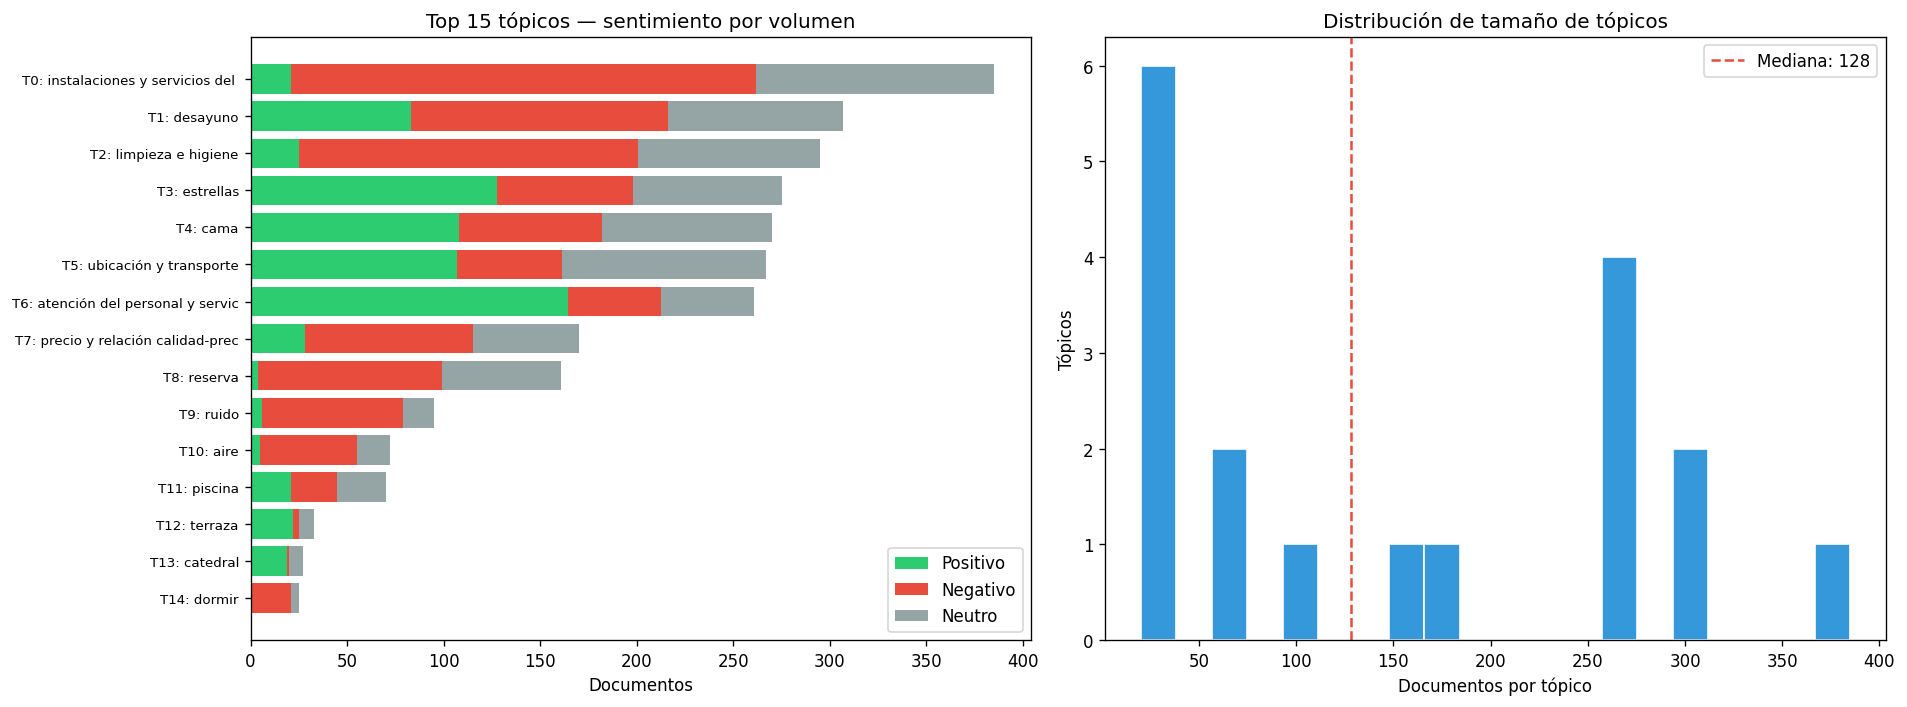

In [20]:
top_n = min(15, n_topics)
top_topics = sorted(topic_sentiment, key=lambda x: topic_sentiment[x]['n_docs'], reverse=True)[:top_n]

labels = []
for t in top_topics:
    words = ', '.join([w for w, _ in topic_model.get_topic(t)[:3]])
    try:
        zs = topic_model.topic_aspects_['ZeroShot'].get(t, [])
        zs_label = zs[0][0] if zs and isinstance(zs[0], (list, tuple)) else str(zs[0]) if zs else words
    except Exception:
        zs_label = words
    labels.append(f'T{t}: {zs_label[:30]}')

pos_abs = [topic_sentiment[t]['POS'] * topic_sentiment[t]['n_docs'] for t in top_topics]
neg_abs = [topic_sentiment[t]['NEG'] * topic_sentiment[t]['n_docs'] for t in top_topics]
neu_abs = [topic_sentiment[t]['NEU'] * topic_sentiment[t]['n_docs'] for t in top_topics]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y = range(len(labels))
axes[0].barh(y, pos_abs, label='Positivo', color='#2ecc71')
axes[0].barh(y, neg_abs, left=pos_abs, label='Negativo', color='#e74c3c')
axes[0].barh(y, neu_abs, left=[p+n for p,n in zip(pos_abs,neg_abs)], label='Neutro', color='#95a5a6')
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].invert_yaxis()
axes[0].legend(loc='lower right')
axes[0].set_title(f'Top {top_n} tópicos — sentimiento por volumen')
axes[0].set_xlabel('Documentos')

axes[1].hist(topic_info['Count'], bins=20, color='#3498db', edgecolor='white')
axes[1].axvline(topic_info['Count'].median(), color='#e74c3c', linestyle='--',
                label=f'Mediana: {topic_info["Count"].median():.0f}')
axes[1].set_title('Distribución de tamaño de tópicos')
axes[1].set_xlabel('Documentos por tópico')
axes[1].set_ylabel('Tópicos')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
# Visualizaciones interactivas de BERTopic
for viz_name, viz_fn in [
    ('barchart',      lambda: topic_model.visualize_barchart(top_n_topics=min(12, n_topics), n_words=8)),
    ('mapa_topicos',  lambda: topic_model.visualize_topics()),
]:
    try:
        fig = viz_fn()
        fig.show()
    except Exception as e:
        print(f'{viz_name} no disponible: {e}')

In [23]:
try:
    hierarchical_topics = topic_model.hierarchical_topics(docs)
    fig_hier = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
    fig_hier.show()
except Exception as e:
    print(f'Jerarquía no disponible: {e}')

100%|██████████| 17/17 [00:01<00:00,  9.41it/s]


## Resultados

In [24]:
results = {
    'topics': topics,
    'probs': probs,
    'topic_info': topic_info,
    'topic_sentiment': topic_sentiment,
    'n_topics': n_topics,
    'coverage': coverage,
    'diversity': diversity,
    'use_sentences': USE_SENTENCES,
    'use_seed_topics': USE_SEED_TOPICS if MODE == 'train' else None,
    'mode': MODE,
}
if USE_SENTENCES:
    results['df_oraciones'] = df_oraciones
    results['review_topics'] = review_topics
    results['avg_aspectos_por_review'] = avg_aspectos

print(f'\nResumen:')
print(f'  Tópicos:           {n_topics}')
print(f'  Cobertura:         {coverage:.1%}')
print(f'  Diversidad léxica: {diversity:.3f}')
if USE_SENTENCES and 'avg_aspectos' in dir():
    print(f'  Aspectos/review:   {avg_aspectos:.2f} (en reviews con al menos 1 tópico)')


Resumen:
  Tópicos:           18
  Cobertura:         61.8%
  Diversidad léxica: 0.911
  Aspectos/review:   2.63 (en reviews con al menos 1 tópico)
